# Tugas - Medical Cost Prediction

| Nama | NRP |
|------|-----|
| Evina Fitriyani| 5054251013 |

## Deskripsi Tugas

Pada tugas ini, kita akan menggunakan Medical Cost Personal Dataset dari Kaggle.

Dataset:
- https://www.kaggle.com/mirichoi0218/insurance

Target yang diprediksi adalah `charges`.

Model yang digunakan:
1. Linear Regression
2. Polynomial Regression
3. Ridge Regression
4. Lasso Regression
5. Decision Tree Regressor
6. Support Vector Regression


# 1. Persiapan Dataset dan Eksplorasi Awal

In [1]:
# Import library yang dibutuhkan.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [2]:
# Load dataset.
# Sesuaikan nama file dengan file dataset yang digunakan.
df = pd.read_csv("insurance.csv")


In [3]:
# Tampilkan beberapa baris pertama dataset.
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
# Tampilkan informasi dataset.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [5]:
# Periksa missing value.
print(df.isnull().sum())

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [6]:
# Tampilkan statistik deskriptif fitur numerik.
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [7]:
# Tampilkan jumlah nilai pada setiap fitur kategorikal.
for col in ['sex', 'smoker', 'region']:
    print(df[col].value_counts())
    print()

sex
male      676
female    662
Name: count, dtype: int64

smoker
no     1064
yes     274
Name: count, dtype: int64

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64



## Lakukan Exploratory Data Analysis (EDA) sederhana yang diperlukan.


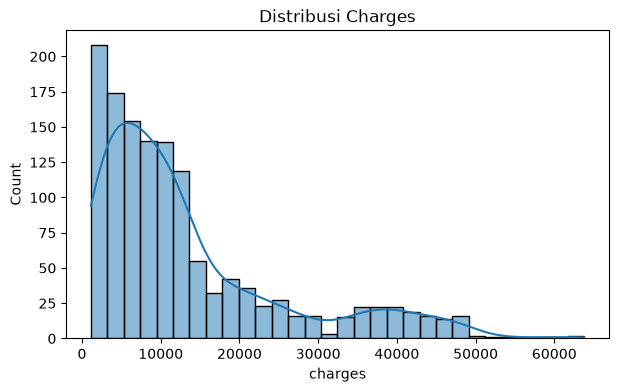

In [8]:
# distribus charges
plt.figure(figsize=(7, 4))
sns.histplot(df['charges'], bins=30, kde=True)
plt.title("Distribusi Charges")
plt.show()

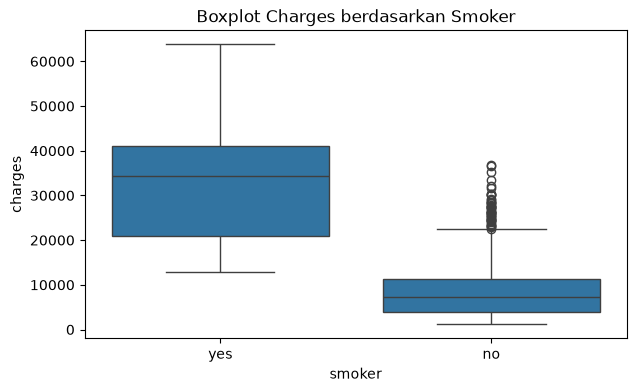

In [9]:
# charges berdasarkan smoker
plt.figure(figsize=(7, 4))
sns.boxplot(x='smoker', y='charges', data=df)
plt.title("Boxplot Charges berdasarkan Smoker")
plt.show()

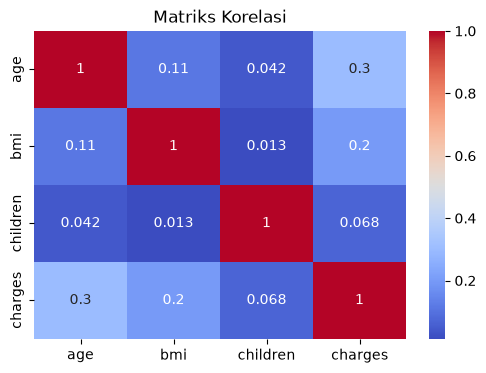

In [10]:
# korelasi antar fitur numerik
plt.figure(figsize=(6, 4))
sns.heatmap(df[['age', 'bmi', 'children', 'charges']].corr(), annot=True, cmap='coolwarm')
plt.title("Matriks Korelasi")
plt.show()

# 2. Preprocessing

Pisahkan fitur numerik dan kategorikal. Gunakan OneHotEncoder untuk fitur kategorikal.

Model Linear Regression, Polynomial Regression, Ridge, Lasso, dan SVR menggunakan data yang telah di-scaling. Decision Tree Regressor tidak memerlukan scaling.


In [11]:
# Pisahkan fitur (X) dan target (y).
X = df.drop('charges', axis=1)
y = df['charges']


In [12]:
# Identifikasi kolom numerik dan kategorikal.
num_cols = ['age', 'bmi', 'children']
cat_cols = ['sex', 'smoker', 'region']
print(num_cols)
print(cat_cols)


['age', 'bmi', 'children']
['sex', 'smoker', 'region']


In [13]:
# Bagi data menjadi train set dan test set.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)

(1070, 6) (268, 6)


In [14]:
# Buat preprocessing untuk fitur numerik dan kategorikal.
# versi scaling (buat Linear, Polynomial, Ridge, Lasso, SVR)
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_cols)
])

X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

# versi tanpa scaling (buat Decision Tree)
preprocessor_tree = ColumnTransformer([
    ('num', 'passthrough', num_cols),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_cols)
])

X_train_tree = preprocessor_tree.fit_transform(X_train)
X_test_tree = preprocessor_tree.transform(X_test)

print(X_train_scaled.shape)
print(X_train_tree.shape)


(1070, 8)
(1070, 8)


# 3. Eksperimen Model

## 3.1 Linear Regression

Bangun model Linear Regression menggunakan data hasil preprocessing.


In [15]:
# Inisialisasi dan latih Linear Regression.
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[3614.98,2036.23, 516.89,...,-370.68,-657.86,-809.8 ]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,8955
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(8)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](8,)","[34.87,32.88,30.58,...,15.8 ,13.03, 8.07]"


In [16]:
# Lakukan prediksi pada test set.
y_pred_lin = lin_reg.predict(X_test_scaled)

## 3.2 Polynomial Regression

Gunakan PolynomialFeatures. Tentukan degree berdasarkan eksperimen.


In [17]:
# Buat fitur polynomial dan latih model.
degree_scores = {}
for d in [1, 2, 3, 4]:
    poly_temp = PolynomialFeatures(degree=d, include_bias=False)
    X_temp = poly_temp.fit_transform(X_train_scaled)
    score = cross_val_score(LinearRegression(), X_temp, y_train, cv=5, scoring='r2').mean()
    degree_scores[d] = score
    print("degree", d, "-> R2 CV:", round(score, 4))

best_degree = max(degree_scores, key=degree_scores.get)
print("degree terbaik:", best_degree)

poly = PolynomialFeatures(degree=best_degree, include_bias=False)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

poly_reg = LinearRegression()
poly_reg.fit(X_train_poly, y_train)

degree 1 -> R2 CV: 0.7331
degree 2 -> R2 CV: 0.8268
degree 3 -> R2 CV: 0.8137
degree 4 -> R2 CV: 0.7128
degree terbaik: 2


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](44,)","[3003.95, 470.76,1455.3 ,...,-713.38, 0. ,-964.09]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,9600
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,44
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(36)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](44,)","[57.66,49.06,43.53,..., 0. , 0. , 0. ]"


In [18]:
# Lakukan prediksi pada test set.
y_pred_poly = poly_reg.predict(X_test_poly)

## 3.3 Ridge Regression

Gunakan Ridge Regression. Tentukan nilai alpha berdasarkan eksperimen.


In [19]:
# Inisialisasi dan latih Ridge Regression.
# cari alpha terbaik
alpha_list = [0.01, 0.1, 1, 10, 100]
ridge_scores = {}
for a in alpha_list:
    score = cross_val_score(Ridge(alpha=a), X_train_scaled, y_train, cv=5, scoring='r2').mean()
    ridge_scores[a] = score
    print("alpha", a, "-> R2 CV:", round(score, 4))

best_alpha_ridge = max(ridge_scores, key=ridge_scores.get)
print("alpha terbaik:", best_alpha_ridge)

ridge_reg = Ridge(alpha=best_alpha_ridge)
ridge_reg.fit(X_train_scaled, y_train)

alpha 0.01 -> R2 CV: 0.7331
alpha 0.1 -> R2 CV: 0.7331
alpha 1 -> R2 CV: 0.7332
alpha 10 -> R2 CV: 0.7308
alpha 100 -> R2 CV: 0.6228
alpha terbaik: 1


,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",1
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to

In [20]:
# Lakukan prediksi pada test set.
y_pred_ridge = ridge_reg.predict(X_test_scaled)

## 3.4 Lasso Regression

Gunakan Lasso Regression. Tentukan nilai alpha berdasarkan eksperimen.


In [21]:
# Inisialisasi dan latih Lasso Regression.
# cari alpha terbaik
alpha_list = [0.01, 0.1, 1, 10, 100]
lasso_scores = {}
for a in alpha_list:
    score = cross_val_score(Lasso(alpha=a, max_iter=10000), X_train_scaled, y_train, cv=5, scoring='r2').mean()
    lasso_scores[a] = score
    print("alpha", a, "-> R2 CV:", round(score, 4))

best_alpha_lasso = max(lasso_scores, key=lasso_scores.get)
print("alpha terbaik:", best_alpha_lasso)

lasso_reg = Lasso(alpha=best_alpha_lasso, max_iter=10000)
lasso_reg.fit(X_train_scaled, y_train)

alpha 0.01 -> R2 CV: 0.7331
alpha 0.1 -> R2 CV: 0.7331
alpha 1 -> R2 CV: 0.7331
alpha 10 -> R2 CV: 0.7333
alpha 100 -> R2 CV: 0.7342
alpha terbaik: 100


,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",100
,"max_iter max_iter: int, default=1000The maximum number of iterations.",10000
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary <warm_start>`.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'
Name,Type,Value


In [22]:
# Lakukan prediksi pada test set.
y_pred_lasso = lasso_reg.predict(X_test_scaled)

## 3.5 Decision Tree Regressor

Gunakan Decision Tree Regressor. Eksperimen dapat dilakukan pada `max_depth` dan `min_samples_leaf`.


In [23]:
# Inisialisasi dan latih Decision Tree Regressor.
# cari max_depth dan min_samples_leaf terbaik
param_tree = {
    'max_depth': [2, 3, 4, 5, 6, 8, 10],
    'min_samples_leaf': [1, 5, 10, 20]
}
grid_tree = GridSearchCV(DecisionTreeRegressor(random_state=42), param_tree, cv=5, scoring='r2')
grid_tree.fit(X_train_tree, y_train)

print("parameter terbaik:", grid_tree.best_params_)
print("R2 CV terbaik:", round(grid_tree.best_score_, 4))

tree_reg = grid_tree.best_estimator_

parameter terbaik: {'max_depth': 4, 'min_samples_leaf': 1}
R2 CV terbaik: 0.8374


In [24]:
# Lakukan prediksi pada test set.
y_pred_tree = tree_reg.predict(X_test_tree)

## 3.6 Support Vector Regression

Gunakan SVR dengan data yang telah di-scaling. Tentukan parameter berdasarkan eksperimen.


In [25]:
# Inisialisasi dan latih SVR.
# cari parameter terbaik dengan kombinasi yang lebih sedikit
param_svr = {
    'C': [100, 1000, 10000],
    'kernel': ['rbf'],
    'gamma': ['scale', 0.01]
}

grid_svr = GridSearchCV(
    SVR(),
    param_svr,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

grid_svr.fit(X_train_scaled, y_train)

print("parameter terbaik:", grid_svr.best_params_)
print("R2 CV terbaik:", round(grid_svr.best_score_, 4))

svr_reg = grid_svr.best_estimator_

parameter terbaik: {'C': 10000, 'gamma': 'scale', 'kernel': 'rbf'}
R2 CV terbaik: 0.8147


In [26]:
# Lakukan prediksi pada test set.
y_pred_svr = svr_reg.predict(X_test_scaled)

# 4. Evaluasi Model

In [27]:
# Hitung MAE, MSE, RMSE, dan R² untuk setiap model.
# Sajikan hasil dalam satu tabel perbandingan.
preds = {
    'Linear Regression': y_pred_lin,
    'Polynomial Regression': y_pred_poly,
    'Ridge Regression': y_pred_ridge,
    'Lasso Regression': y_pred_lasso,
    'Decision Tree': y_pred_tree,
    'SVR': y_pred_svr
}

hasil = []
for nama, y_pred in preds.items():
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    hasil.append([nama, mae, mse, rmse, r2])

df_hasil = pd.DataFrame(hasil, columns=['Model', 'MAE', 'MSE', 'RMSE', 'R2'])
df_hasil = df_hasil.sort_values('R2', ascending=False).reset_index(drop=True)
df_hasil

,Model,MAE,MSE,RMSE,R2
0,Polynomial Regression,2729.500134,2.071281e+07,4551.132385,0.866583
1,Decision Tree,2697.765431,2.109348e+07,4592.764310,0.864131
2,SVR,1860.565154,2.510565e+07,5010.554142,0.838288
3,Linear Regression,4181.194474,3.359692e+07,5796.284659,0.783593
4,Ridge Regression,4193.195353,3.364539e+07,5800.464938,0.783281
5,Lasso Regression,4248.492453,3.426606e+07,5853.722107,0.779283


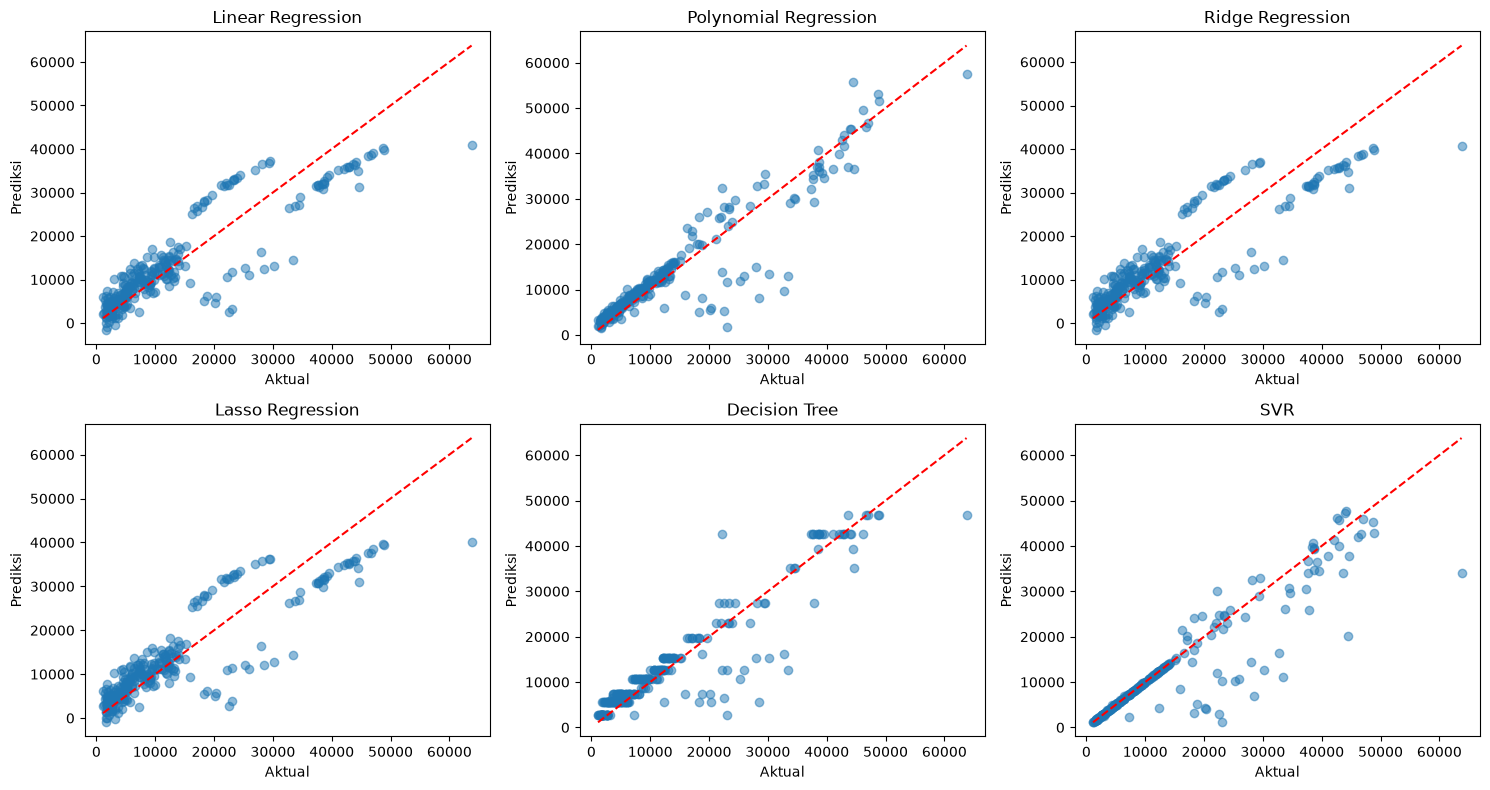

In [28]:
# Buat visualisasi perbandingan nilai aktual dan prediksi jika diperlukan.
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, (nama, y_pred) in enumerate(preds.items()):
    axes[i].scatter(y_test, y_pred, alpha=0.5)
    axes[i].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    axes[i].set_title(nama)
    axes[i].set_xlabel("Aktual")
    axes[i].set_ylabel("Prediksi")

plt.tight_layout()
plt.show()

# 5. Analisis

#### Bandingkan hasil Linear Regression, Polynomial Regression, Ridge, Lasso, Decision Tree Regressor, dan SVR berdasarkan metrik evaluasi. Jelaskan pengaruh preprocessing dan parameter yang digunakan terhadap hasil.

### Perbandingan Hasil Model

Hasil evaluasi keenam model pada data test adalah sebagai berikut:

| Model | MAE | RMSE | R² |
|---|---:|---:|---:|
| **Polynomial Regression** | 2729.50 | 4551.13 | **0.8666** |
| Decision Tree | 2697.77 | 4592.76 | 0.8641 |
| SVR | **1860.57** | 5010.55 | 0.8383 |
| Linear Regression | 4181.19 | 5796.28 | 0.7836 |
| Ridge Regression | 4193.20 | 5800.46 | 0.7833 |
| Lasso Regression | 4248.49 | 5853.72 | 0.7793 |

Berdasarkan tabel, **Polynomial Regression** memberikan performa keseluruhan terbaik dengan nilai R² tertinggi sebesar **0.8666** dan RMSE sebesar **4551.13**. Model ini menggunakan **degree = 2**, yang merupakan degree terbaik berdasarkan cross-validation dengan R² CV sebesar **0.8268**.

**Decision Tree** memiliki hasil yang hampir sama dengan Polynomial Regression, yaitu R² **0.8641** dan RMSE **4592.76**. Parameter terbaik yang diperoleh adalah `max_depth = 4` dan `min_samples_leaf = 1`, dengan R² CV sebesar **0.8374**.

Sementara itu, **SVR memiliki MAE paling rendah**, yaitu **1860.57**. Namun, nilai R² sebesar **0.8383** masih berada di bawah Polynomial Regression dan Decision Tree. Parameter terbaik SVR adalah `C = 10000`, `gamma = scale`, dan `kernel = rbf`, dengan R² CV sebesar **0.8147**.

### Pengaruh Preprocessing dan Parameter

Pada preprocessing, fitur numerik yaitu `age`, `bmi`, dan `children` dilakukan standardisasi menggunakan **StandardScaler**, sedangkan fitur kategorikal `sex`, `smoker`, dan `region` diubah menggunakan **OneHotEncoder**.

Scaling terutama membantu model seperti **Polynomial Regression, Ridge, Lasso, dan SVR** karena model tersebut lebih dipengaruhi oleh skala fitur. Untuk Decision Tree digunakan preprocessing tanpa scaling karena model berbasis pohon tidak bergantung pada skala fitur.

Hasil pencarian parameter menunjukkan bahwa:
- Polynomial Regression → **degree = 2**
- Ridge Regression → **alpha = 1**
- Lasso Regression → **alpha = 100**
- Decision Tree → **max_depth = 4, min_samples_leaf = 1**
- SVR → **C = 10000, gamma = scale, kernel = rbf**

Pemilihan parameter tersebut dilakukan menggunakan cross-validation pada data train sehingga test set tetap digunakan untuk evaluasi akhir.

### Hasil EDA

Dari distribusi `charges`, terlihat bahwa data cenderung **miring ke kanan**, dengan sebagian besar nilai berada pada rentang yang lebih rendah dan beberapa nilai yang jauh lebih tinggi.

Pada boxplot, kelompok **smoker = yes** memiliki nilai `charges` yang jauh lebih tinggi dibandingkan kelompok `smoker = no`. Hal ini menunjukkan bahwa status merokok memiliki hubungan yang cukup kuat dengan biaya asuransi.

Berdasarkan matriks korelasi, korelasi fitur numerik terhadap `charges` adalah:

| Fitur | Korelasi dengan Charges |
|---|---:|
| `age` | 0.30 |
| `bmi` | 0.20 |
| `children` | 0.068 |

`age` memiliki korelasi numerik paling tinggi dengan `charges`, tetapi nilainya masih tergolong sedang. Oleh karena itu, penggunaan model yang dapat menangkap hubungan non-linear seperti Polynomial Regression dapat memberikan hasil yang lebih baik.

# 6. Kesimpulan dan Saran

#### Berikan kesimpulan berdasarkan hasil eksperimen. Saran dapat berupa perubahan parameter, preprocessing, atau eksperimen lanjutan.

### Kesimpulan

Berdasarkan hasil eksperimen, **Polynomial Regression dengan degree = 2** merupakan model dengan performa keseluruhan terbaik pada dataset insurance. Model tersebut memperoleh **R² sebesar 0.8666**, sehingga sekitar **86.66% variasi nilai charges** dapat dijelaskan oleh model pada data test.

Decision Tree memberikan performa yang hampir sama dengan R² sebesar **0.8641**, sedangkan SVR memiliki **MAE paling rendah sebesar 1860.57**. Linear Regression, Ridge Regression, dan Lasso menghasilkan nilai R² yang lebih rendah, yaitu sekitar **0.78**.

Hasil EDA juga menunjukkan bahwa `charges` memiliki distribusi yang miring ke kanan dan terdapat perbedaan yang cukup jelas antara charges pada kelompok perokok dan non-perokok. Hal ini menunjukkan bahwa fitur kategorikal seperti `smoker` juga penting dalam proses prediksi.

### Saran

Untuk pengembangan selanjutnya, eksperimen dapat dilakukan dengan:

1. Mencoba **transformasi log pada target `charges`** karena distribusinya cenderung miring ke kanan.
2. Melakukan **tuning parameter yang lebih luas** pada SVR dan Decision Tree.
3. Membandingkan hasil dengan model lain seperti **Random Forest Regressor** atau **Gradient Boosting Regressor**.
4. Menganalisis **feature importance** untuk mengetahui fitur yang paling berpengaruh terhadap `charges`.
